In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
from math import gamma

import qutip as qt
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from psyduck import Spin
from psyduck.operations import *
from psyduck.hamiltonians import *
from psyduck.plotting import *

<Axes: >

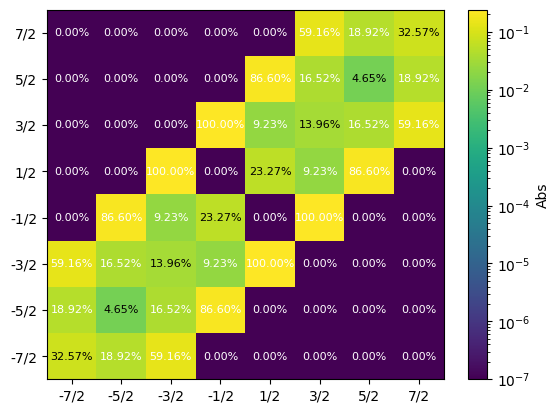

In [3]:
H_quad_real = np.load('../quadrupole modeling/H_quad_fit.npy') # from fit
plot_transition_matrix(H_quad_real)

<Axes: >

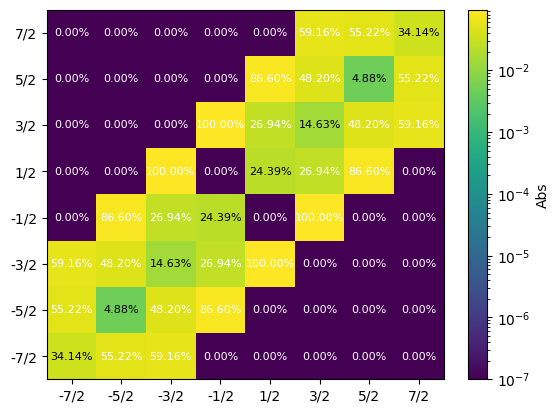

In [4]:
# I = 7/2
# e = 1.6e-19
# h = 6.626e-3
# Q = -0.556e-28  # nuclear quadrupole moment

H_quad = quadrupole_hamiltonian(7/2, -44e-3, eta=0.9, theta=np.pi/3)

plot_transition_matrix(H_quad.full())

In [6]:
Ix, Iy, Iz = get_spin_operators(7/2)
Sx, Sy, Sz = get_spin_operators(1/2)

Iz2 = Iz*Iz
Ix2 = Ix*Ix

# All freqs are in MHz

B0 = 1.4
A = 97.5
fq = -44.1e-3
gamma_n = 5.55
gamma_e = 28.8e3
I = 7/2

# H_hyperfine = A * (qt.tensor(Sx, Ix) + qt.tensor(Sy, Iy) + qt.tensor(Sz, Iz))
H_hyperfine = hyperfine_hamiltonian(1/2, 7/2, A)
H_quad = quadrupole_hamiltonian(I, fq, eta=0.9, theta=np.pi/3)

H0_ionized = B0 * gamma_n * Iz  # 8x8
H0_neutral = B0 * (qt.tensor(gamma_e*Sz, qt.qeye(8)) + qt.tensor(qt.qeye(2), gamma_n*Iz))  # 16x16

H_ionized = -H0_ionized - H_quad
H_neutral = -H0_neutral - H_hyperfine + qt.tensor(qt.qeye(2), H_quad)

<Axes: >

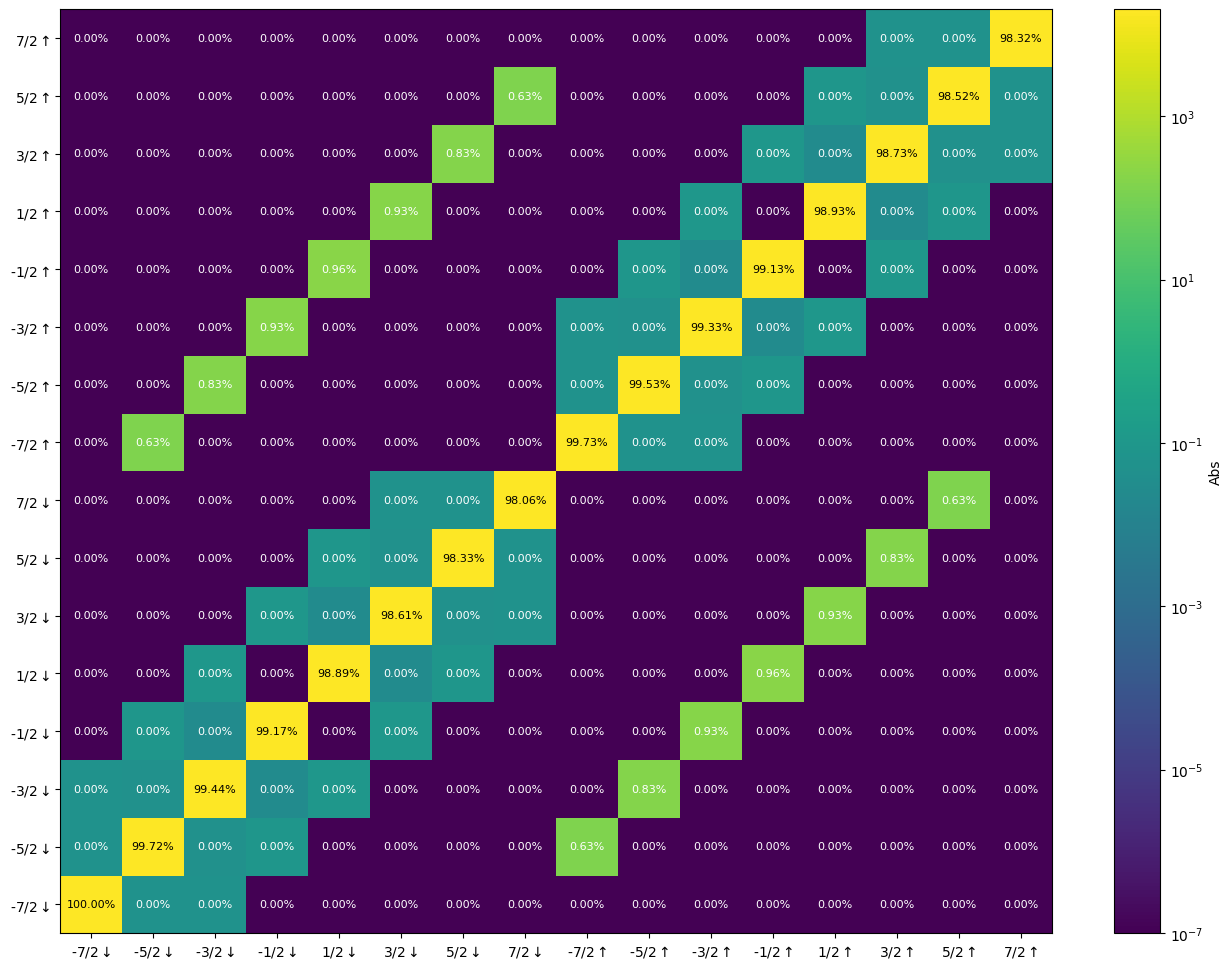

In [7]:
fig, ax = plt.subplots(1,1, figsize=(16,12))
plot_transition_matrix(H_neutral.full(), electron_states=2, ax=ax)

<Axes: title={'center': 'Nuclear Eigenstates of the Hamiltonian'}>

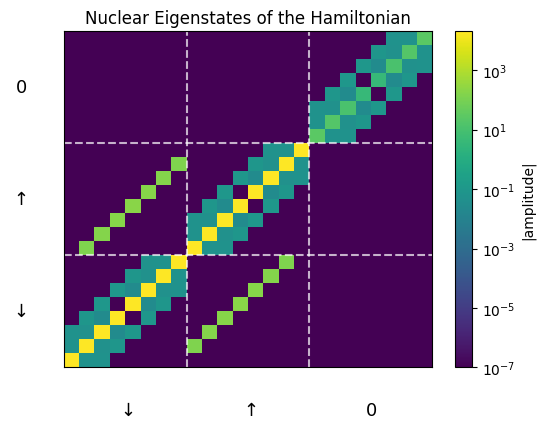

In [8]:
# Now let's combine both H_neutral and H_ionized

proj_donor = qt.tensor(qt.Qobj([[1,0],[0,1],[0,0]]), qt.qeye(8))  # project onto the donor
H_neutral_full = proj_donor @ H_neutral @ proj_donor.dag()

# |2><2| âŠ— H_ionized embeds H_ionized into the SET (3rd electron) subspace
e_SET = qt.basis(3, 2)
H_ionized_full = qt.tensor(e_SET * e_SET.dag(), H_ionized)

H_full = H_neutral_full + H_ionized_full

# plt.pcolor(np.abs(H_full.full()))
# plot_transition_matrix(H_full.full(), electron_states=3)
plot_transition_matrix_simplified(H_full.full(), electron_states=3)

In [9]:
H_ionized

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=CSR, isherm=True
Qobj data =
[[-2.71622006e+01  5.30490419e-02  5.68382592e-02  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 5.30490419e-02 -1.94203144e+01  4.63050000e-02  8.32026919e-02
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 5.68382592e-02  4.63050000e-02 -1.16690569e+01  2.58852819e-02
   9.60741931e-02  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  8.32026919e-02  2.58852819e-02 -3.90842812e+00
   0.00000000e+00  9.60741931e-02  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  9.60741931e-02  0.00000000e+00
   3.86157187e+00 -2.58852819e-02  8.32026919e-02  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  9.60741931e-02
  -2.58852819e-02  1.16409431e+01 -4.63050000e-02  5.68382592e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   8.32026919e-02 -4.63050000e-02  1.9429

In [10]:
qt.tensor(Sz, Iz)

Quantum object: dims=[[2, 8], [2, 8]], shape=(16, 16), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 1.75  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
   0.    0.    0.    0.  ]
 [ 0.    1.25  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
   0.    0.    0.    0.  ]
 [ 0.    0.    0.75  0.    0.    0.    0.    0.    0.    0.    0.    0.
   0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.25  0.    0.    0.    0.    0.    0.    0.    0.
   0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.   -0.25  0.    0.    0.    0.    0.    0.    0.
   0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.   -0.75  0.    0.    0.    0.    0.    0.
   0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.   -1.25  0.    0.    0.    0.    0.
   0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.   -1.75  0.    0.    0.    0.
   0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.    0.   -1.75  0.    0.    0.
   0.    0.    0.    0.  ]
 [ 0. 

In [11]:
I = [1/2, 7/2]
H = qt.tensor(qt.qeye(2*i) for i in I)
H

Quantum object: dims=[[1, 7.0], [1, 7.0]], shape=(7, 7), type='oper', dtype=Dia, isherm=True
Qobj data =
[[1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1.]]

In [12]:
zeeman_hamiltonian([1/2, 7/2], 1.4, [gamma_e, gamma_n]) + H0_neutral

Quantum object: dims=[[2, 8], [2, 8]], shape=(16, 16), type='oper', dtype=CSR, isherm=True
Qobj data =
[[-3.63797881e-12  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0

In [13]:
H0_neutral

Quantum object: dims=[[2, 8], [2, 8]], shape=(16, 16), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 20187.195      0.         0.         0.         0.         0.
       0.         0.         0.         0.         0.         0.
       0.         0.         0.         0.   ]
 [     0.     20179.425      0.         0.         0.         0.
       0.         0.         0.         0.         0.         0.
       0.         0.         0.         0.   ]
 [     0.         0.     20171.655      0.         0.         0.
       0.         0.         0.         0.         0.         0.
       0.         0.         0.         0.   ]
 [     0.         0.         0.     20163.885      0.         0.
       0.         0.         0.         0.         0.         0.
       0.         0.         0.         0.   ]
 [     0.         0.         0.         0.     20156.115      0.
       0.         0.         0.         0.         0.         0.
       0.         0.         0.         0.   ]
 [     0.   